# Classical Computer Vision: Feature Extraction

This notebook explores handcrafted image features for casting defect classification.

The goal is to understand what information each feature extracts from the images before training classical machine learning models.

The following feature extraction methods will be explored:

- Raw pixel values
- Image histograms
- Sobel edges
- Canny edges
- LBP (Local Binary Patterns)
- HOG (Histogram of Oriented Gradients)
- GLCM (Gray-Level Co-occurrence Matrix)

Visualization is performed using sample images only. The full training and validation datasets will be used later for model benchmarking.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
DATA_DIR = Path("../data/raw/casting_data/casting_data")

TRAIN_DIR = DATA_DIR / "train"

In [3]:
defective_files = list((TRAIN_DIR / "def_front").glob("*.jpeg"))
ok_files = list((TRAIN_DIR / "ok_front").glob("*.jpeg"))

defective_path = defective_files[0]
ok_path = ok_files[0]

print("Defective:", defective_path)
print("OK:", ok_path)

Defective: ..\data\raw\casting_data\casting_data\train\def_front\cast_def_0_0.jpeg
OK: ..\data\raw\casting_data\casting_data\train\ok_front\cast_ok_0_1.jpeg


In [4]:
defective_image = cv2.imread(str(defective_path))
ok_image = cv2.imread(str(ok_path))

defective_gray = cv2.cvtColor(defective_image, cv2.COLOR_BGR2GRAY)
ok_gray = cv2.cvtColor(ok_image, cv2.COLOR_BGR2GRAY)

print("Defective shape:", defective_image.shape)
print("OK shape:", ok_image.shape)

Defective shape: (300, 300, 3)
OK shape: (300, 300, 3)


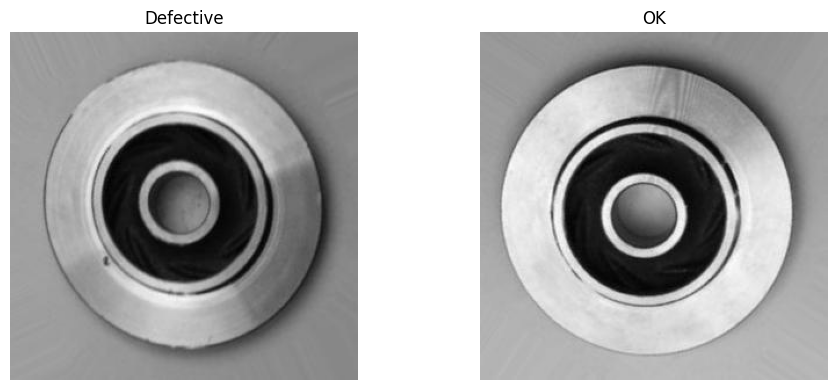

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(defective_image, cv2.COLOR_BGR2RGB))
plt.title("Defective")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(ok_image, cv2.COLOR_BGR2RGB))
plt.title("OK")
plt.axis("off")

plt.tight_layout()
plt.show()

## 1. Image Histogram

An image histogram shows the distribution of pixel intensity values.

For grayscale images, pixel values range from 0 to 255:

- 0 represents black.
- 255 represents white.

The histogram can help describe the overall brightness and intensity distribution of the casting surface.

In [6]:
defective_hist = cv2.calcHist(
    [defective_gray],
    [0],
    None,
    [256],
    [0, 256]
)

ok_hist = cv2.calcHist(
    [ok_gray],
    [0],
    None,
    [256],
    [0, 256]
)

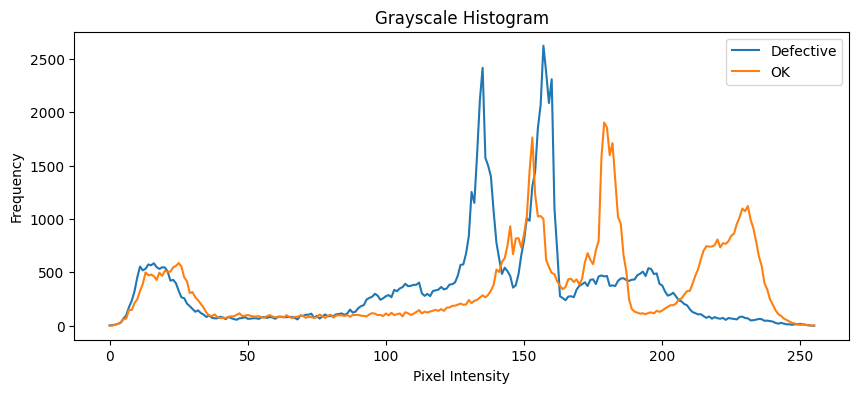

In [7]:
plt.figure(figsize=(10, 4))

plt.plot(defective_hist, label="Defective")
plt.plot(ok_hist, label="OK")

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Grayscale Histogram")
plt.legend()
plt.show()

In [8]:
print("Defective")
print("Mean:", defective_gray.mean())
print("Std:", defective_gray.std())
print("Min:", defective_gray.min())
print("Max:", defective_gray.max())

print("\nOK")
print("Mean:", ok_gray.mean())
print("Std:", ok_gray.std())
print("Min:", ok_gray.min())
print("Max:", ok_gray.max())

Defective
Mean: 132.11546666666666
Std: 53.446092058613395
Min: 0
Max: 254

OK
Mean: 154.26347777777778
Std: 65.90083654429885
Min: 0
Max: 255


### Interpretation

The histogram provides global information about pixel intensity distribution.

However, it does not contain explicit spatial information. Two images can have similar histograms while having very different spatial structures.

Therefore, histogram features may provide useful global information, but they may not be sufficient to identify localized casting defects on their own.

## 2. Sobel Edge Detection

Sobel detects changes in pixel intensity along the horizontal and vertical directions.

It is useful for capturing edges and structural information that may be affected by casting defects.

In [9]:
sobel_x = cv2.Sobel(
    defective_gray,
    cv2.CV_64F,
    1, 0,
    ksize=3
)

sobel_y = cv2.Sobel(
    defective_gray,
    cv2.CV_64F,
    0, 1,
    ksize=3
)

sobel_magnitude = cv2.magnitude(
    np.float32(np.abs(sobel_x)),
    np.float32(np.abs(sobel_y))
)

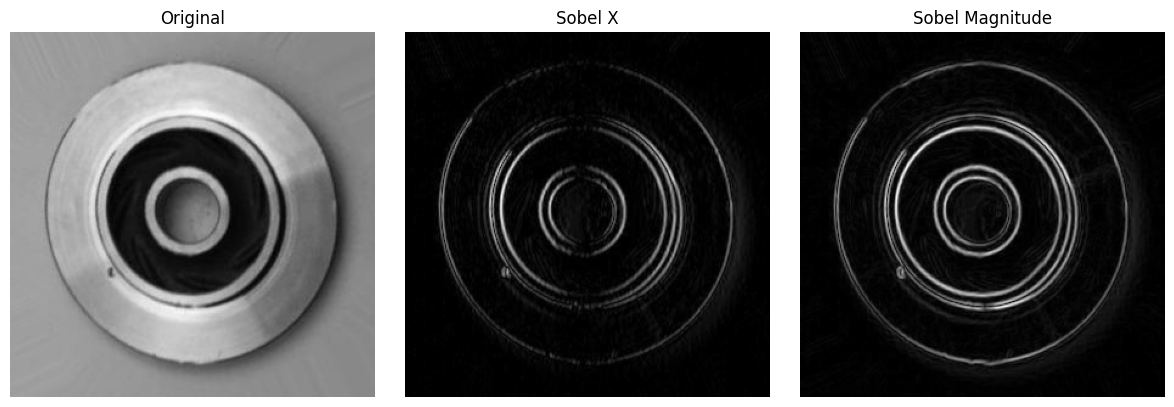

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(defective_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Canny Edge Detection

Canny detects prominent edges in an image using multiple processing steps.

Unlike Sobel, Canny produces a binary edge map that highlights detected boundaries.

In [11]:
canny = cv2.Canny(
    defective_gray,
    50,
    150
)

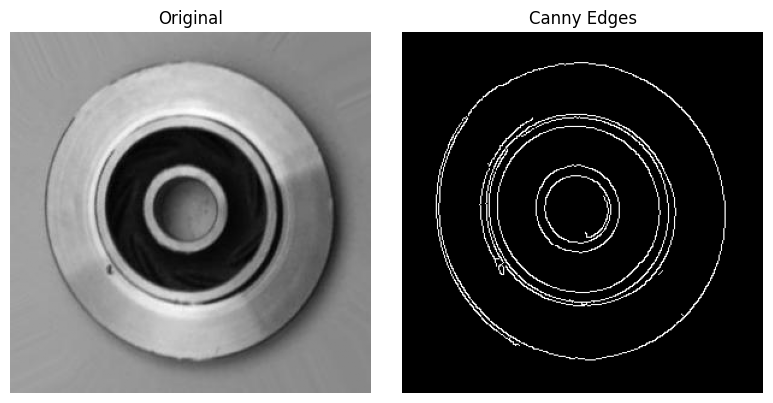

In [12]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(defective_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Local Binary Patterns (LBP)

LBP describes local texture patterns by comparing each pixel with its neighboring pixels.

It can capture small texture variations that may be useful for detecting surface defects.

In [13]:
from skimage.feature import local_binary_pattern

In [14]:
radius = 1
points = 8 * radius

lbp = local_binary_pattern(
    defective_gray,
    points,
    radius,
    method="uniform"
)

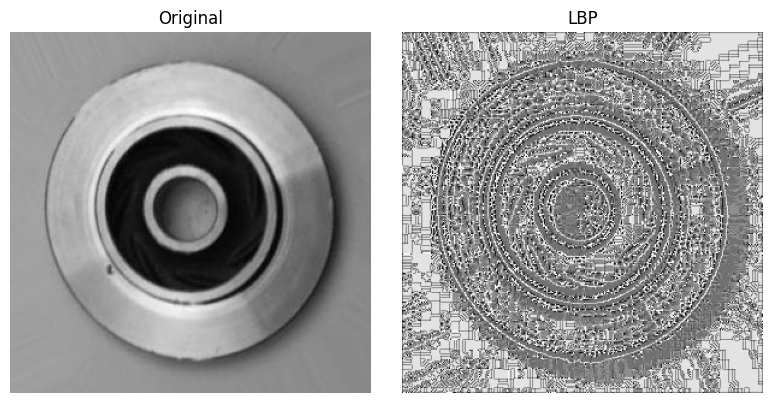

In [15]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(defective_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lbp, cmap="gray")
plt.title("LBP")
plt.axis("off")

plt.tight_layout()
plt.show()

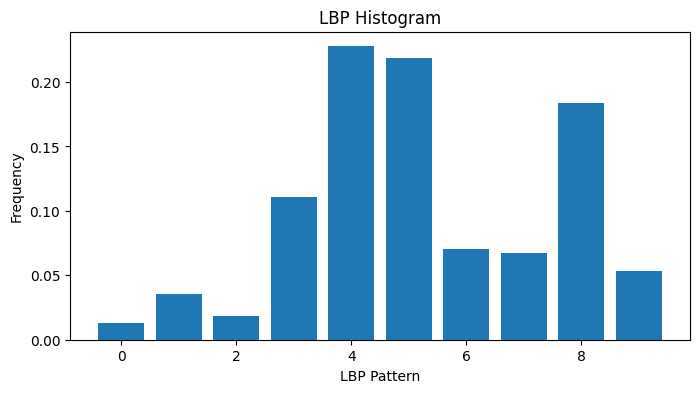

In [16]:
n_bins = points + 2

lbp_hist, _ = np.histogram(
    lbp.ravel(),
    bins=n_bins,
    range=(0, n_bins),
    density=True
)

plt.figure(figsize=(8, 4))

plt.bar(
    range(n_bins),
    lbp_hist
)

plt.xlabel("LBP Pattern")
plt.ylabel("Frequency")
plt.title("LBP Histogram")
plt.show()

## 5. Histogram of Oriented Gradients (HOG)

HOG describes the structure of an image using local gradient directions.

It is commonly used to represent shapes, contours, and structural patterns.

In [17]:
from skimage.feature import hog

In [18]:
hog_features, hog_image = hog(
    defective_gray,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    visualize=True
)

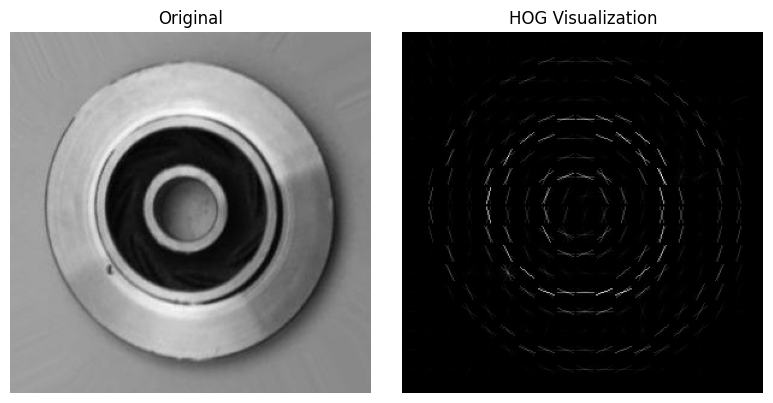

In [19]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(defective_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
print("HOG feature shape:", hog_features.shape)
print("Number of features:", len(hog_features))

HOG feature shape: (10404,)
Number of features: 10404


## 6. Gray-Level Co-occurrence Matrix (GLCM)

GLCM describes how often pairs of pixel intensities occur next to each other.

It provides statistical information about image texture.

Common GLCM properties include:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation

In [21]:
from skimage.feature import graycomatrix, graycoprops

In [22]:
# Reduce intensity levels to make the matrix smaller
gray_small = (defective_gray // 32).astype(np.uint8)

glcm = graycomatrix(
    gray_small,
    distances=[1],
    angles=[0],
    levels=8,
    symmetric=True,
    normed=True
)

In [23]:
contrast = graycoprops(glcm, "contrast")[0, 0]
dissimilarity = graycoprops(glcm, "dissimilarity")[0, 0]
homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
energy = graycoprops(glcm, "energy")[0, 0]
correlation = graycoprops(glcm, "correlation")[0, 0]

print("Contrast:", contrast)
print("Dissimilarity:", dissimilarity)
print("Homogeneity:", homogeneity)
print("Energy:", energy)
print("Correlation:", correlation)

Contrast: 0.1294648829431438
Dissimilarity: 0.11312151616499441
Homogeneity: 0.9450735785953176
Energy: 0.4580914828246814
Correlation: 0.9775319960544725


## Feature Visualization Summary

The extracted features describe different aspects of the casting images:

- Histogram → global intensity distribution
- Sobel → intensity gradients and edges
- Canny → prominent boundaries
- LBP → local texture patterns
- HOG → structural and gradient information
- GLCM → statistical texture properties

These representations will be used in the next stage for classical machine learning experiments.